In [10]:
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
#/Users/judyhedayah/Desktop/2026-orion-1/data/egx/ADIB_.csv


df = pd.read_csv("/Users/judyhedayah/Desktop/2026-orion-1/data/egx/ADIB_.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.reset_index(drop=True)

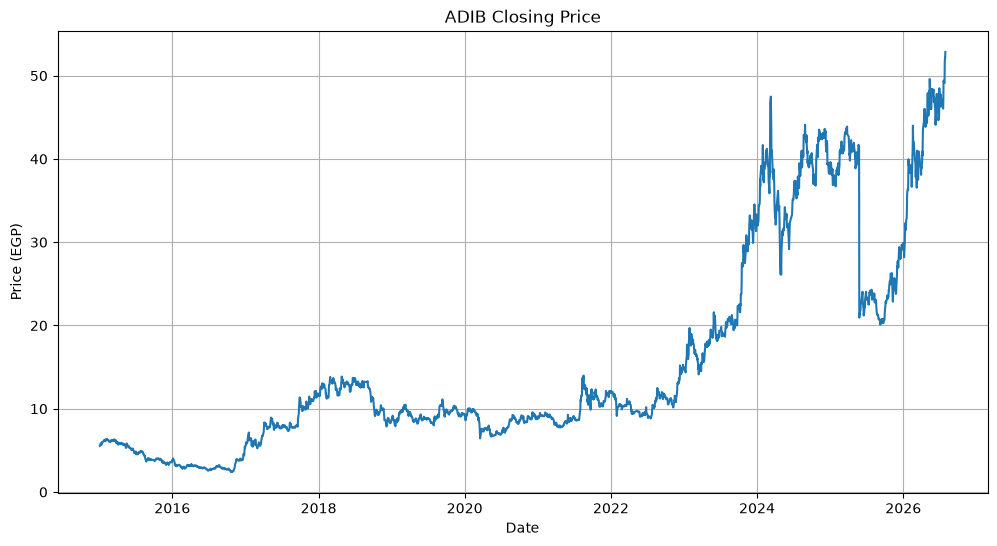

In [12]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["close"])

plt.title("ADIB Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (EGP)")

plt.grid(True)

plt.show()

In [13]:
df["MA9"] = df["close"].rolling(9).mean()
df["MA20"] = df["close"].rolling(20).mean()

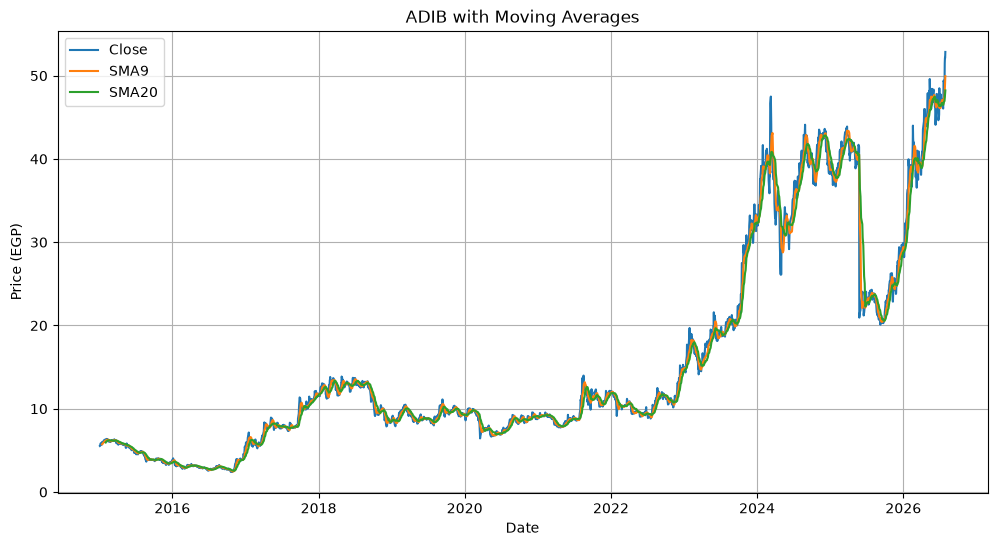

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["close"], label="Close")
plt.plot(df["date"], df["MA9"], label="SMA9")
plt.plot(df["date"], df["MA20"], label="SMA20")

plt.title("ADIB with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (EGP)")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
# ==========================
# WALK-FORWARD BACKTEST
# ==========================

cash = 1000          # Starting money (EGP)
shares = 0           # Number of shares currently owned

buy_count = 0
sell_count = 0

portfolio_values = []

buy_dates = []
buy_prices = []

sell_dates = []
sell_prices = []


# Walk through every trading day
for i in range(len(df)):

    # Today's information
    date = df.loc[i, "date"]
    price = df.loc[i, "close"]
    ma9 = df.loc[i, "MA9"]
    ma20 = df.loc[i, "MA20"]

    # Skip rows where moving averages don't exist yet
    if pd.isna(ma9) or pd.isna(ma20):
        continue

    # BUY SIGNAL
    if ma9 > ma20 and shares == 0:

        shares = cash / price
        cash = 0

        buy_count += 1

        buy_dates.append(date)
        buy_prices.append(price)

    # SELL SIGNAL
    elif ma9 < ma20 and shares > 0:

        cash = shares * price
        shares = 0

        sell_count += 1

        sell_dates.append(date)
        sell_prices.append(price)

    # Calculate today's portfolio value
    portfolio = cash + (shares * price)
    portfolio_values.append(portfolio)

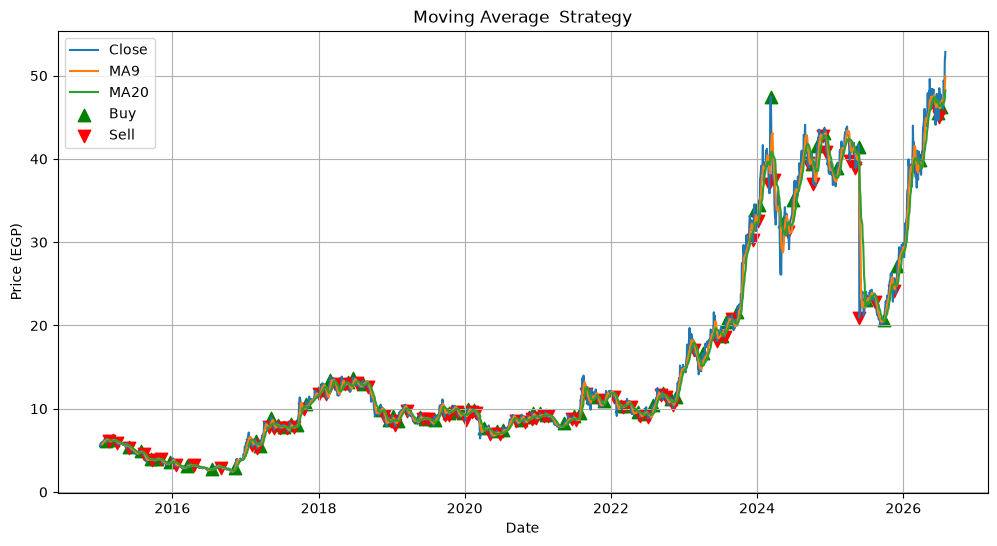

In [16]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["close"], label="Close")
plt.plot(df["date"], df["MA9"], label="MA9")
plt.plot(df["date"], df["MA20"], label="MA20")

plt.scatter(
    buy_dates,
    buy_prices,
    marker="^",
    color="green",
    s=80,
    label="Buy"
)

plt.scatter(
    sell_dates,
    sell_prices,
    marker="v",
    color="red",
    s=80,
    label="Sell"
)

plt.title("Moving Average  Strategy")
plt.xlabel("Date")
plt.ylabel("Price (EGP)")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
print(f"Final Portfolio Value: {portfolio_values[-1]:.2f} EGP")
print(f"Number of Buys: {buy_count}")
print(f"Number of Sells: {sell_count}")

portfolio_series = pd.Series(portfolio_values)

running_max = portfolio_series.cummax()

drawdown = (portfolio_series - running_max) / running_max

max_drawdown = drawdown.min() * 100

print(f"Maximum Drawdown: {max_drawdown:.2f}%")

print(drawdown)

Final Portfolio Value: 2464.18 EGP
Number of Buys: 78
Number of Sells: 77
Maximum Drawdown: -66.08%
0       0.000000
1       0.000000
2       0.000000
3       0.000000
4      -0.008343
          ...   
2837   -0.302542
2838   -0.268890
2839   -0.259519
2840   -0.260087
2841   -0.249580
Length: 2842, dtype: float64
